PART 1.1 — SIMPLE EXPONENTIAL SMOOTHING

Dataset:
   Day  Process_Yield
0    1          85.75
1    2          84.79
2    3          85.97
3    4          87.28
4    5          84.65

Number of observations: 45


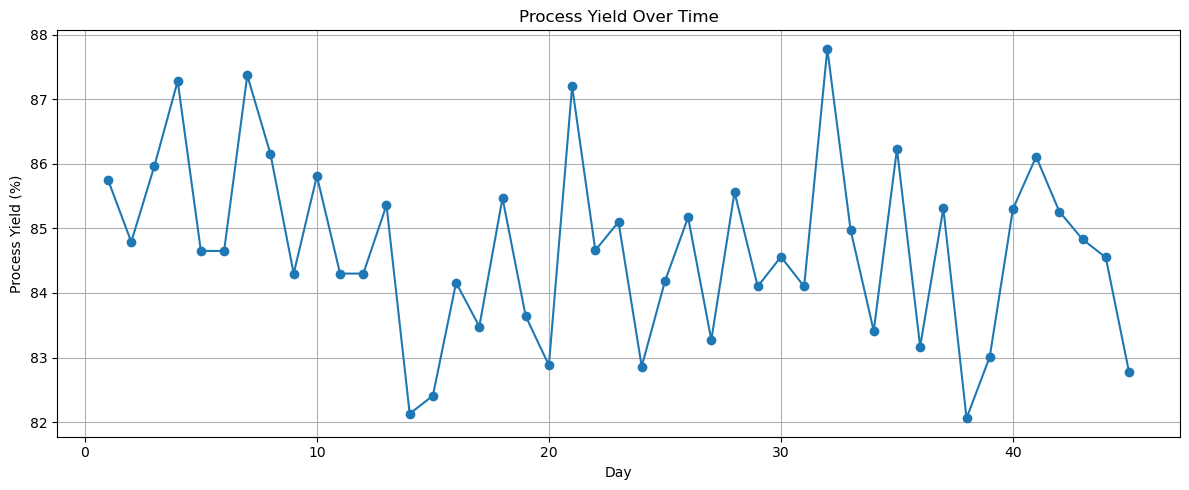


SES ACCURACY COMPARISON
 Alpha      MSE  MAPE (%)
   0.2 2.094310  1.359680
   0.4 2.313471  1.455813

Best smoothing constant: alpha = 0.20
Forecast for Day 46: 84.3351%


PART 1.2 — HOLT'S LINEAR EXPONENTIAL SMOOTHING

Dataset:
   Month  Sales_Thousands
0      1           119.98
1      2           123.39
2      3           131.20
3      4           131.20
4      5           126.33

Number of observations: 36


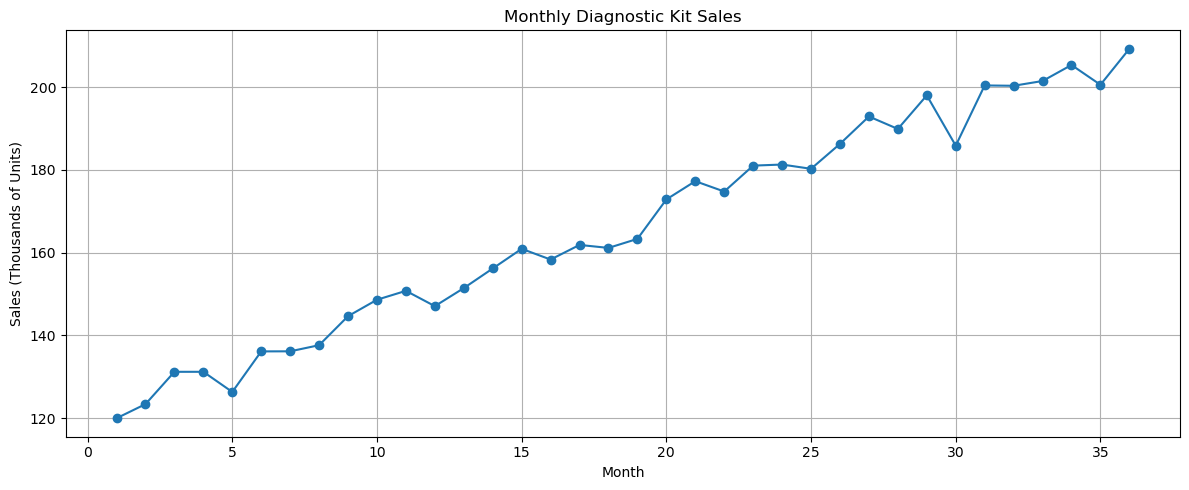


HOLT'S FINAL LEVEL AND TREND
Level at Month 36: 207.7154
Trend at Month 36: 2.0718

OUT-OF-SAMPLE FORECASTS
Month 37 forecast: 209.7871
Month 38 forecast: 211.8589


PART 2.1 — ARIMA MODEL: SERVER MEMORY LOAD

Dataset:
   Day  Memory_Load_Pct
0    1            61.89
1    2            60.17
2    3            62.80
3    4            61.16
4    5            66.19

Number of observations: 100


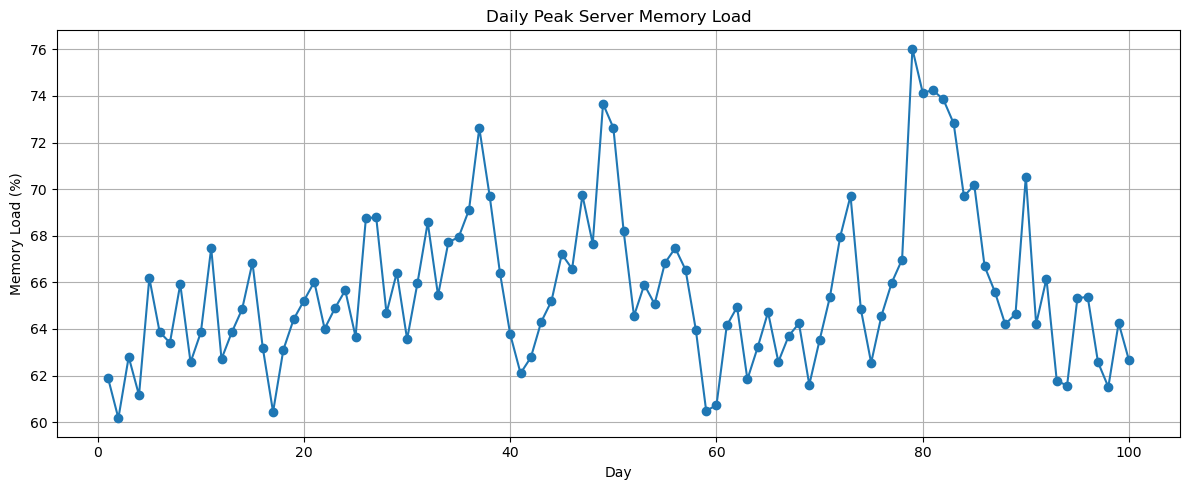

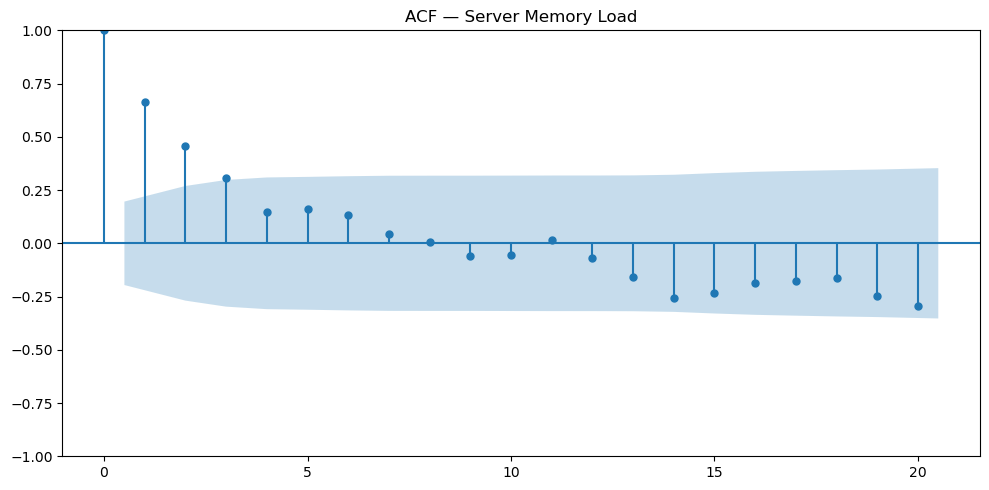

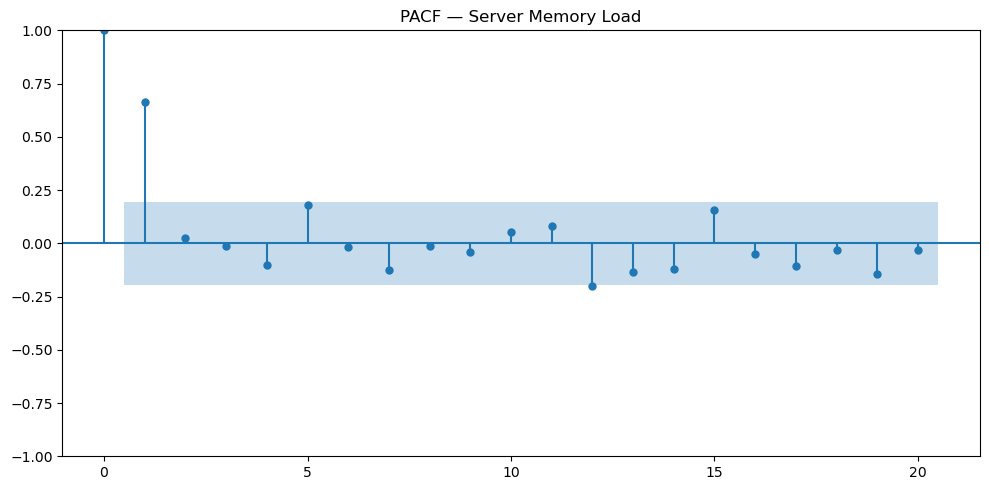


Tentative ARIMA model:
ARIMA(1, 0, 0)

ARIMA(1,0,0) MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:        Memory_Load_Pct   No. Observations:                  100
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -232.634
Date:                Tue, 06 Oct 2026   AIC                            471.268
Time:                        10:27:45   BIC                            479.083
Sample:                             0   HQIC                           474.431
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         65.5628      0.813     80.633      0.000      63.969      67.156
ar.L1          0.6734      0.089      7.571      0.000       0.4

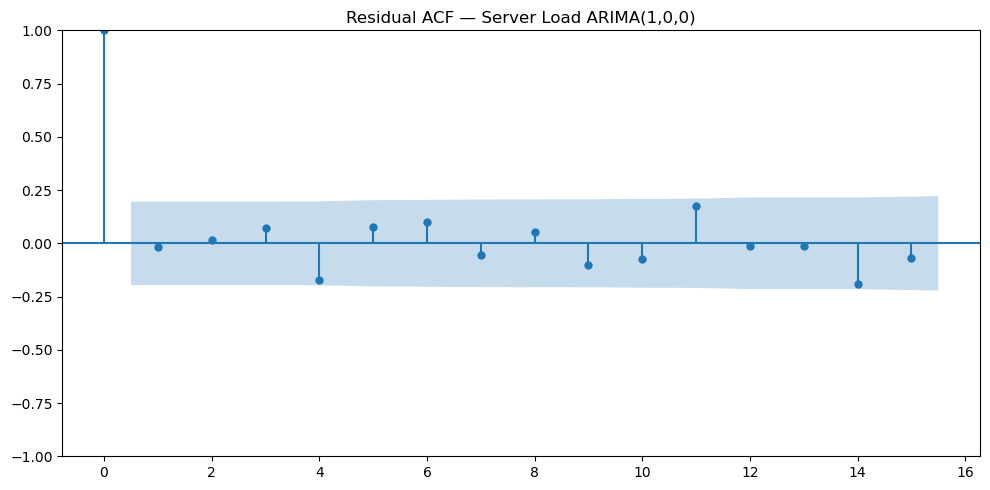


SERVER LOAD LJUNG-BOX TEST
    lb_stat  lb_pvalue
15  16.2701   0.364331

Conclusion: Residuals behave approximately as WHITE NOISE.

SERVER LOAD FORECASTS
Memory_Load_Pct       mean  mean_ci_lower  mean_ci_upper
100              63.608147      58.766253      68.450041
101              64.246594      58.409313      70.083875


PART 2.2 — ARIMA MODEL: POWER DEMAND

Dataset:
   Day  Power_Demand_MW
0    1           350.00
1    2           347.30
2    3           357.18
3    4           355.43
4    5           346.06

Number of observations: 120


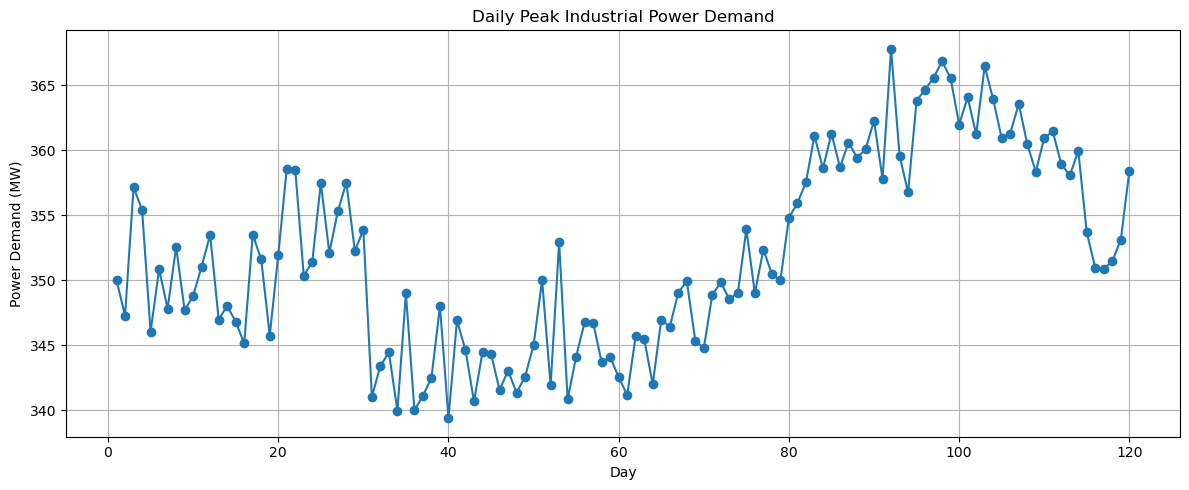

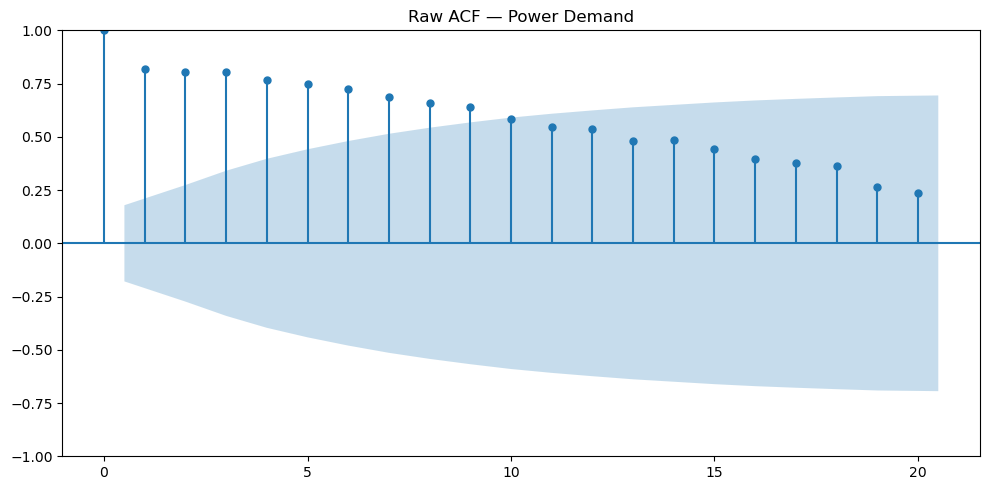

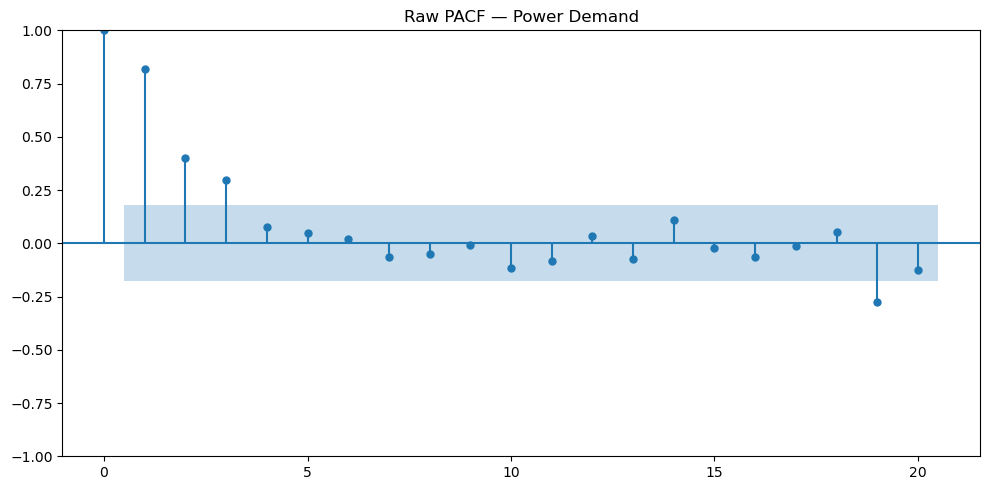


Original observations: 120
Differenced observations: 119


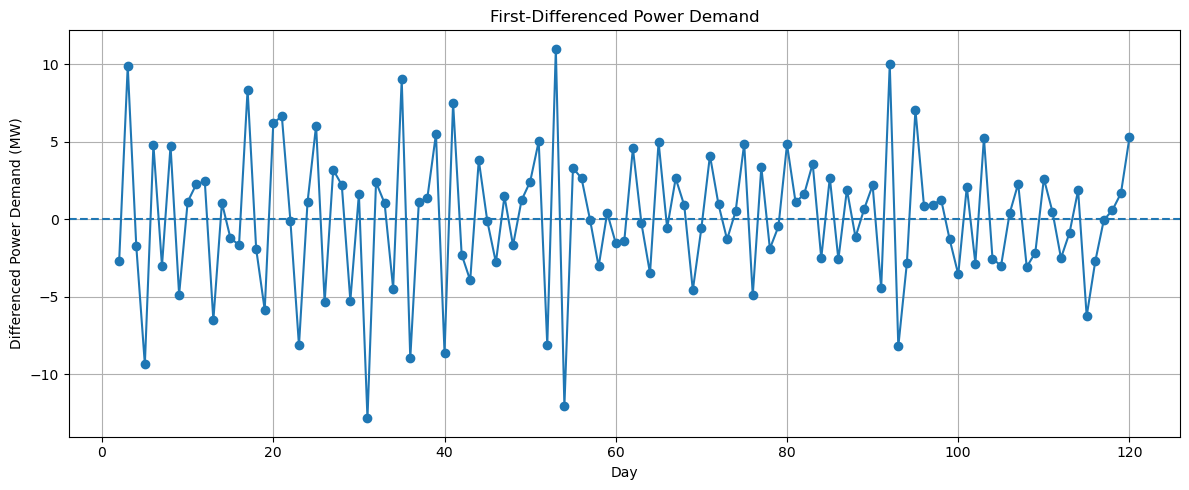

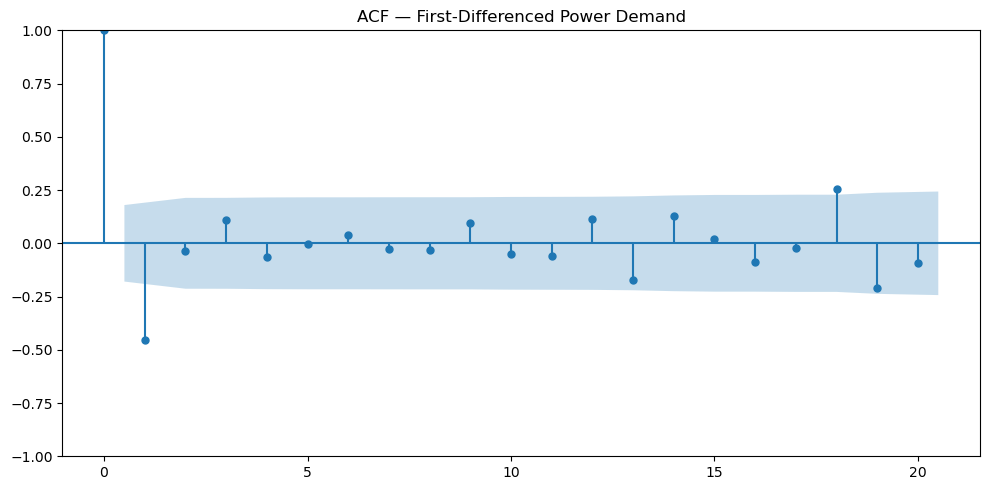

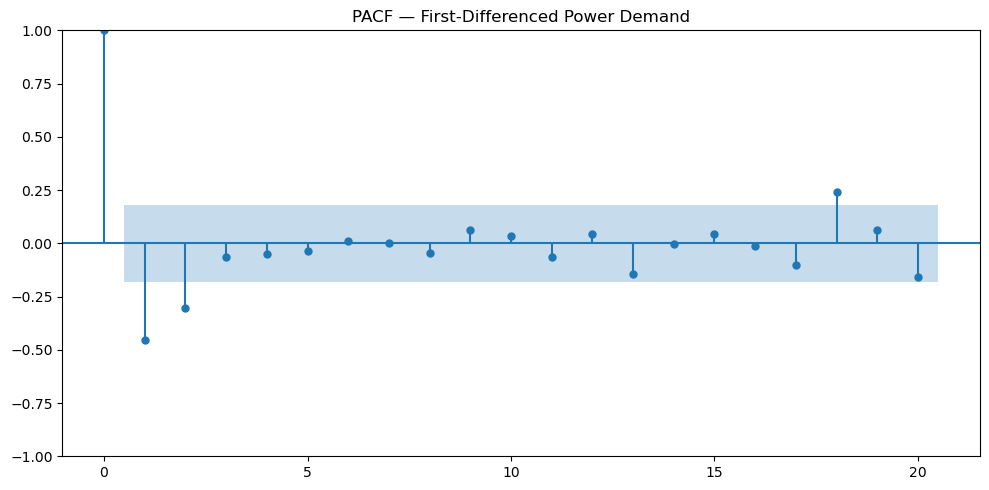


Tentative ARIMA model:
ARIMA(0, 1, 1)

ARIMA(0,1,1) MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:        Power_Demand_MW   No. Observations:                  120
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -326.744
Date:                Tue, 06 Oct 2026   AIC                            657.488
Time:                        10:27:47   BIC                            663.047
Sample:                             0   HQIC                           659.745
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5884      0.069     -8.475      0.000      -0.724      -0.452
sigma2        14.1546      1.705      8.300      0.000      10.8

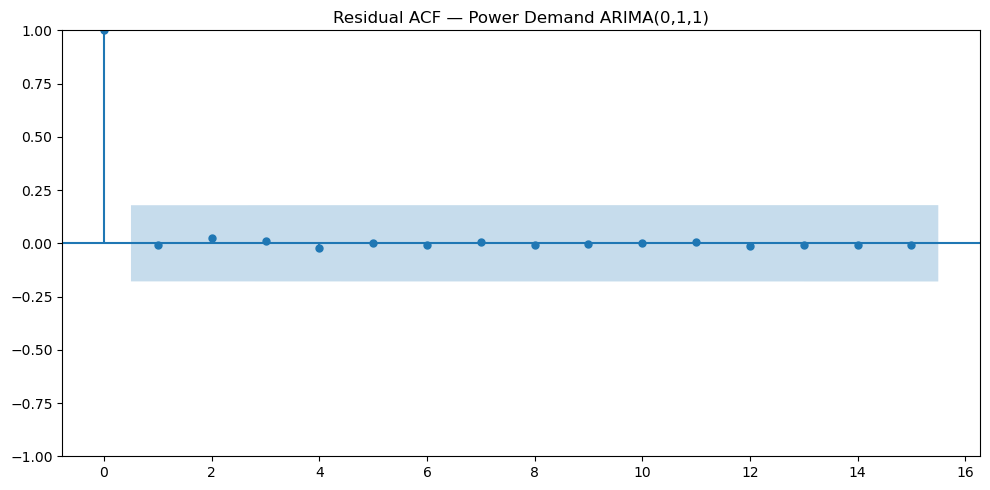


POWER DEMAND LJUNG-BOX TEST
     lb_stat  lb_pvalue
15  0.246771        1.0

Conclusion: Residuals behave approximately as WHITE NOISE.

POWER DEMAND FORECASTS
Power_Demand_MW       mean  mean_ci_lower  mean_ci_upper
120              355.07048     347.696579     362.444381
121              355.07048     347.096321     363.044638


FINAL RESULTS SUMMARY

PART 1.1 — SES
α = 0.20 → MSE = 2.09431, MAPE = 1.35968%
α = 0.40 → MSE = 2.31347, MAPE = 1.45581%
Best α = 0.20
Day 46 Forecast = 84.3351%

PART 1.2 — HOLT
α = 0.30, β = 0.20
Level at Month 36 = 207.7154
Trend at Month 36 = 2.0718
Month 37 Forecast = 209.7871
Month 38 Forecast = 211.8589

PART 2.1 — SERVER LOAD
Model = ARIMA(1,0,0)
Memory_Load_Pct       mean  mean_ci_lower  mean_ci_upper
100              63.608147      58.766253      68.450041
101              64.246594      58.409313      70.083875

PART 2.2 — POWER DEMAND
Model = ARIMA(0,1,1)
Power_Demand_MW       mean  mean_ci_lower  mean_ci_upper
120              355.07048     347

In [1]:
# ============================================================
# APM1215 — FA3
# EXPONENTIAL SMOOTHING AND ARIMA MODELS
# COMPLETE ONE-CELL PYTHON CODE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# ------------------------------------------------------------
# FILE NAMES
# ------------------------------------------------------------

SES_FILE = "ses-process-yield.csv"
HOLT_FILE = "holts-medical-sales.csv"
SERVER_FILE = "arima-server-load.csv"
POWER_FILE = "arima-power-demand.csv"


# ============================================================
# PART 1.1 — SIMPLE EXPONENTIAL SMOOTHING
# ============================================================

print("=" * 80)
print("PART 1.1 — SIMPLE EXPONENTIAL SMOOTHING")
print("=" * 80)

# Import dataset
ses_df = pd.read_csv(SES_FILE)

print("\nDataset:")
print(ses_df.head())
print("\nNumber of observations:", len(ses_df))

# Identify columns automatically
day_col = ses_df.columns[0]
yield_col = ses_df.columns[1]

days = ses_df[day_col].values
y = ses_df[yield_col].astype(float).values


# ------------------------------------------------------------
# A. Exploratory Time Series Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(days, y, marker="o")
plt.title("Process Yield Over Time")
plt.xlabel("Day")
plt.ylabel("Process Yield (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# B. SES FUNCTION
# Initial forecast = first observation
# ------------------------------------------------------------

def simple_exponential_smoothing(y, alpha):

    forecasts = np.zeros(len(y))

    # Initial forecast
    forecasts[0] = y[0]

    # 1-step-ahead forecasts
    for t in range(1, len(y)):
        forecasts[t] = (
            alpha * y[t-1]
            + (1 - alpha) * forecasts[t-1]
        )

    return forecasts


# Alpha = 0.20
alpha_020 = 0.20
forecast_020 = simple_exponential_smoothing(y, alpha_020)

# Alpha = 0.40
alpha_040 = 0.40
forecast_040 = simple_exponential_smoothing(y, alpha_040)


# ------------------------------------------------------------
# C. MSE AND MAPE
# Evaluate Days 2 through 45
# ------------------------------------------------------------

actual = y[1:]

pred_020 = forecast_020[1:]
pred_040 = forecast_040[1:]


mse_020 = np.mean((actual - pred_020) ** 2)
mse_040 = np.mean((actual - pred_040) ** 2)

mape_020 = np.mean(
    np.abs((actual - pred_020) / actual)
) * 100

mape_040 = np.mean(
    np.abs((actual - pred_040) / actual)
) * 100


ses_results = pd.DataFrame({
    "Alpha": [0.20, 0.40],
    "MSE": [mse_020, mse_040],
    "MAPE (%)": [mape_020, mape_040]
})

print("\nSES ACCURACY COMPARISON")
print(ses_results.to_string(index=False))


# Determine best alpha
if mse_020 < mse_040:
    best_alpha = 0.20
    best_forecast = forecast_020
else:
    best_alpha = 0.40
    best_forecast = forecast_040


print(f"\nBest smoothing constant: alpha = {best_alpha:.2f}")


# ------------------------------------------------------------
# D. Forecast Day 46
# ------------------------------------------------------------

day_46_forecast = (
    best_alpha * y[-1]
    + (1 - best_alpha) * best_forecast[-1]
)

print(f"Forecast for Day 46: {day_46_forecast:.4f}%")


# ============================================================
# PART 1.2 — HOLT'S LINEAR EXPONENTIAL SMOOTHING
# ============================================================

print("\n\n" + "=" * 80)
print("PART 1.2 — HOLT'S LINEAR EXPONENTIAL SMOOTHING")
print("=" * 80)

# Import dataset
holt_df = pd.read_csv(HOLT_FILE)

print("\nDataset:")
print(holt_df.head())
print("\nNumber of observations:", len(holt_df))

month_col = holt_df.columns[0]
sales_col = holt_df.columns[1]

months = holt_df[month_col].values
sales = holt_df[sales_col].astype(float).values


# ------------------------------------------------------------
# A. Trend Identification Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(months, sales, marker="o")
plt.title("Monthly Diagnostic Kit Sales")
plt.xlabel("Month")
plt.ylabel("Sales (Thousands of Units)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# B. Holt's Linear Exponential Smoothing
# alpha = 0.30
# beta = 0.20
#
# L1 = y1
# T1 = y2 - y1
# ------------------------------------------------------------

alpha = 0.30
beta = 0.20

n = len(sales)

level = np.zeros(n)
trend = np.zeros(n)

# Initialization
level[0] = sales[0]
trend[0] = sales[1] - sales[0]

# Recursive calculations
for t in range(1, n):

    level[t] = (
        alpha * sales[t]
        + (1 - alpha) * (level[t-1] + trend[t-1])
    )

    trend[t] = (
        beta * (level[t] - level[t-1])
        + (1 - beta) * trend[t-1]
    )


L36 = level[-1]
T36 = trend[-1]


# ------------------------------------------------------------
# C. Forecast Months 37 and 38
# ------------------------------------------------------------

forecast_37 = L36 + (1 * T36)
forecast_38 = L36 + (2 * T36)

print("\nHOLT'S FINAL LEVEL AND TREND")
print(f"Level at Month 36: {L36:.4f}")
print(f"Trend at Month 36: {T36:.4f}")

print("\nOUT-OF-SAMPLE FORECASTS")
print(f"Month 37 forecast: {forecast_37:.4f}")
print(f"Month 38 forecast: {forecast_38:.4f}")


# ============================================================
# PART 2.1 — ARIMA MODEL FOR SERVER LOAD
# ============================================================

print("\n\n" + "=" * 80)
print("PART 2.1 — ARIMA MODEL: SERVER MEMORY LOAD")
print("=" * 80)

# Import dataset
server_df = pd.read_csv(SERVER_FILE)

print("\nDataset:")
print(server_df.head())
print("\nNumber of observations:", len(server_df))

server_day_col = server_df.columns[0]
server_value_col = server_df.columns[1]

server_days = server_df[server_day_col].values
server_y = server_df[server_value_col].astype(float)


# ------------------------------------------------------------
# A. Time Series Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(server_days, server_y, marker="o")
plt.title("Daily Peak Server Memory Load")
plt.xlabel("Day")
plt.ylabel("Memory Load (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# A. ACF up to lag 20
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(server_y, lags=20, ax=ax)
ax.set_title("ACF — Server Memory Load")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# A. PACF up to lag 20
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(server_y, lags=20, ax=ax, method="ywm")
ax.set_title("PACF — Server Memory Load")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# B. Model Identification
# ARIMA(1,0,0)
# ------------------------------------------------------------

server_order = (1, 0, 0)

print("\nTentative ARIMA model:")
print("ARIMA(1, 0, 0)")


# ------------------------------------------------------------
# C. Fit ARIMA Model
# ------------------------------------------------------------

server_model = ARIMA(
    server_y,
    order=server_order
)

server_result = server_model.fit()

print("\nARIMA(1,0,0) MODEL SUMMARY")
print(server_result.summary())


# ------------------------------------------------------------
# Estimated Parameters
# ------------------------------------------------------------

print("\nESTIMATED PARAMETERS")
print(server_result.params)


# ------------------------------------------------------------
# D. Residual Diagnostics
# ------------------------------------------------------------

server_residuals = server_result.resid

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(
    server_residuals,
    lags=15,
    ax=ax
)
ax.set_title("Residual ACF — Server Load ARIMA(1,0,0)")
plt.tight_layout()
plt.show()


# Ljung-Box test
server_lb = acorr_ljungbox(
    server_residuals,
    lags=[15],
    return_df=True
)

print("\nSERVER LOAD LJUNG-BOX TEST")
print(server_lb)

server_p = server_lb["lb_pvalue"].iloc[0]

if server_p > 0.05:
    print("\nConclusion: Residuals behave approximately as WHITE NOISE.")
else:
    print("\nConclusion: Significant residual autocorrelation remains.")


# ------------------------------------------------------------
# E. Forecast 1-step and 2-step
# ------------------------------------------------------------

server_forecast = server_result.get_forecast(steps=2)

server_forecast_table = server_forecast.summary_frame(
    alpha=0.05
)

print("\nSERVER LOAD FORECASTS")
print(
    server_forecast_table[
        ["mean", "mean_ci_lower", "mean_ci_upper"]
    ]
)


# ============================================================
# PART 2.2 — ARIMA MODEL FOR POWER DEMAND
# ============================================================

print("\n\n" + "=" * 80)
print("PART 2.2 — ARIMA MODEL: POWER DEMAND")
print("=" * 80)

# Import dataset
power_df = pd.read_csv(POWER_FILE)

print("\nDataset:")
print(power_df.head())
print("\nNumber of observations:", len(power_df))

power_day_col = power_df.columns[0]
power_value_col = power_df.columns[1]

power_days = power_df[power_day_col].values
power_y = power_df[power_value_col].astype(float)


# ------------------------------------------------------------
# A. Raw Time Series
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(power_days, power_y, marker="o")
plt.title("Daily Peak Industrial Power Demand")
plt.xlabel("Day")
plt.ylabel("Power Demand (MW)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# A. Raw ACF
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(power_y, lags=20, ax=ax)
ax.set_title("Raw ACF — Power Demand")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# A. Raw PACF
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(power_y, lags=20, ax=ax, method="ywm")
ax.set_title("Raw PACF — Power Demand")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# B. First Differencing
# ------------------------------------------------------------

power_diff = power_y.diff().dropna()

print("\nOriginal observations:", len(power_y))
print("Differenced observations:", len(power_diff))


# ------------------------------------------------------------
# Differenced Time Series Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(
    power_days[1:],
    power_diff,
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("First-Differenced Power Demand")
plt.xlabel("Day")
plt.ylabel("Differenced Power Demand (MW)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# C. Differenced ACF
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(power_diff, lags=20, ax=ax)
ax.set_title("ACF — First-Differenced Power Demand")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# C. Differenced PACF
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(
    power_diff,
    lags=20,
    ax=ax,
    method="ywm"
)
ax.set_title("PACF — First-Differenced Power Demand")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Model Identification
# ARIMA(0,1,1)
# ------------------------------------------------------------

power_order = (0, 1, 1)

print("\nTentative ARIMA model:")
print("ARIMA(0, 1, 1)")


# ------------------------------------------------------------
# D. Fit ARIMA(0,1,1)
# ------------------------------------------------------------

power_model = ARIMA(
    power_y,
    order=power_order
)

power_result = power_model.fit()

print("\nARIMA(0,1,1) MODEL SUMMARY")
print(power_result.summary())


# ------------------------------------------------------------
# Estimated Parameters
# ------------------------------------------------------------

print("\nESTIMATED PARAMETERS")
print(power_result.params)


# ------------------------------------------------------------
# E. Residual Diagnostics
# ------------------------------------------------------------

power_residuals = power_result.resid

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(
    power_residuals,
    lags=15,
    ax=ax
)

ax.set_title("Residual ACF — Power Demand ARIMA(0,1,1)")
plt.tight_layout()
plt.show()


# Ljung-Box test
power_lb = acorr_ljungbox(
    power_residuals,
    lags=[15],
    return_df=True
)

print("\nPOWER DEMAND LJUNG-BOX TEST")
print(power_lb)

power_p = power_lb["lb_pvalue"].iloc[0]

if power_p > 0.05:
    print("\nConclusion: Residuals behave approximately as WHITE NOISE.")
else:
    print("\nConclusion: Significant residual autocorrelation remains.")


# ------------------------------------------------------------
# Forecast 1-step and 2-step
# ------------------------------------------------------------

power_forecast = power_result.get_forecast(
    steps=2
)

power_forecast_table = power_forecast.summary_frame(
    alpha=0.05
)

print("\nPOWER DEMAND FORECASTS")
print(
    power_forecast_table[
        ["mean", "mean_ci_lower", "mean_ci_upper"]
    ]
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n\n" + "=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)

print("\nPART 1.1 — SES")
print(f"α = 0.20 → MSE = {mse_020:.5f}, MAPE = {mape_020:.5f}%")
print(f"α = 0.40 → MSE = {mse_040:.5f}, MAPE = {mape_040:.5f}%")
print(f"Best α = {best_alpha:.2f}")
print(f"Day 46 Forecast = {day_46_forecast:.4f}%")

print("\nPART 1.2 — HOLT")
print(f"α = {alpha:.2f}, β = {beta:.2f}")
print(f"Level at Month 36 = {L36:.4f}")
print(f"Trend at Month 36 = {T36:.4f}")
print(f"Month 37 Forecast = {forecast_37:.4f}")
print(f"Month 38 Forecast = {forecast_38:.4f}")

print("\nPART 2.1 — SERVER LOAD")
print("Model = ARIMA(1,0,0)")
print(server_forecast_table[["mean", "mean_ci_lower", "mean_ci_upper"]])

print("\nPART 2.2 — POWER DEMAND")
print("Model = ARIMA(0,1,1)")
print(power_forecast_table[["mean", "mean_ci_lower", "mean_ci_upper"]])

print("\n" + "=" * 80)
print("FA3 ANALYSIS COMPLETE")
print("=" * 80)